# SAM Nucleus Segmentation — RAM-Optimized Pipeline
### PanNuke | SAM ViT-B | Google Colab Free Tier Safe

## RAM optimizations applied:
| Technique | RAM saved |
|---|---|
| `mmap_mode='r'` for numpy arrays | ~1.5 GB |
| Delete masks/tensors after each image | ~200 MB/image |
| `torch.no_grad()` everywhere | ~50% GPU RAM |
| Skip micro-sam / patho-sam install | ~300 MB |
| Process one image at a time, no list accumulation | ~500 MB |
| `gc.collect()` + `torch.cuda.empty_cache()` each loop | stable |
| Resize to 256 not 512 | 4x less GPU memory per image |
| Dual AMG: strict only (no permissive fallback stored) | ~100 MB |
| Smart sampling: skip empty images before loading | avoids wasted runs |

**Expected RAM usage: ~5-7 GB (safe for Colab free T4)**

## Section 1 — Install (minimal, no heavy repos)

In [ ]:
# RAM optimization: skip patho-sam and micro-sam installs
# They are NOT needed for SAM ViT-B inference
# They consume ~300 MB of RAM after import
!pip install segment-anything scikit-image opencv-python-headless matplotlib --quiet
print('Installed. Note: patho-sam/micro-sam skipped to save RAM.')

Installed. Note: patho-sam/micro-sam skipped to save RAM.


## Section 2 — Imports + RAM Utilities

In [ ]:
import gc
import torch
import torch.nn.functional as F
import cv2
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from skimage.measure import label, regionprops
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from skimage.morphology import remove_small_objects, disk, binary_closing
from scipy import ndimage as ndi
from sklearn.metrics import precision_score, recall_score, f1_score
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor

# ── RAM monitoring utility ────────────────────────────────────
def print_ram():
    """Print current RAM and GPU memory usage."""
    try:
        import psutil
        ram = psutil.virtual_memory()
        print(f'RAM: {ram.used/1e9:.1f}/{ram.total/1e9:.1f} GB '
              f'({ram.percent:.0f}%)', end='')
    except ImportError:
        pass
    if torch.cuda.is_available():
        alloc = torch.cuda.memory_allocated()/1e9
        resrv = torch.cuda.memory_reserved()/1e9
        print(f'  |  GPU alloc={alloc:.2f}GB reserved={resrv:.2f}GB', end='')
    print()

def free_ram():
    """
    Force garbage collection and clear CUDA cache.
    Call this after every image to prevent memory buildup.
    """
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print('Imports done.')
print(f'CUDA: {torch.cuda.is_available()}')
print_ram()

Imports done.
CUDA: True
RAM: 1.3/13.6 GB (12%)  |  GPU alloc=0.00GB reserved=0.00GB


## Section 3 — All Helper Functions

In [ ]:
# ════════════════════════════════════════════════════════════
# [E1] MACENKO STAIN NORMALISATION
# RAM tip: transform() creates one small array per image,
# old array is garbage collected immediately after.
# ════════════════════════════════════════════════════════════

class MacenkoNormalizer:
    def __init__(self, beta=0.15, alpha=1.0):
        self.beta = beta
        self.alpha = alpha
        self.HERef = None
        self.maxCRef = None

    def _to_od(self, img_flat):
        img_flat = img_flat.astype(np.float64) + 1e-6
        OD = -np.log(img_flat / 255.0)
        OD[(OD < self.beta).any(axis=1)] = 0
        return OD

    def _get_stain_matrix(self, OD):
        OD_valid = OD[~(OD == 0).any(axis=1)]
        if len(OD_valid) < 10:
            return np.eye(3, 2)
        _, V = np.linalg.eigh(np.cov(OD_valid.T))
        V = V[:, [2, 1]]
        if V[0, 0] < 0: V[:, 0] *= -1
        if V[0, 1] < 0: V[:, 1] *= -1
        that = OD_valid @ V
        phi  = np.arctan2(that[:, 1], that[:, 0])
        vMin = V @ np.array([[np.cos(np.percentile(phi, self.alpha))],
                              [np.sin(np.percentile(phi, self.alpha))]])
        vMax = V @ np.array([[np.cos(np.percentile(phi, 100-self.alpha))],
                              [np.sin(np.percentile(phi, 100-self.alpha))]])
        HE = np.hstack([vMin, vMax]) if vMin[0] > vMax[0] else np.hstack([vMax, vMin])
        return HE

    def fit(self, target_img):
        OD = self._to_od(target_img.reshape(-1, 3))
        self.HERef = self._get_stain_matrix(OD)
        C = np.linalg.lstsq(self.HERef, OD.T, rcond=None)[0]
        self.maxCRef = np.percentile(C, 99, axis=1)
        print('[E1] Normaliser fitted.')

    def transform(self, source_img):
        if self.HERef is None:
            return source_img
        h, w, _ = source_img.shape
        OD = self._to_od(source_img.reshape(-1, 3))
        try:
            HE   = self._get_stain_matrix(OD)
            C    = np.linalg.lstsq(HE, OD.T, rcond=None)[0]
            maxC = np.percentile(C, 99, axis=1)
            C    = C / (maxC[:, None] + 1e-6) * self.maxCRef[:, None]
            out  = np.clip(np.exp(-(self.HERef @ C).T) * 255, 0, 255).astype(np.uint8)
            return out.reshape(h, w, 3)
        except Exception:
            return source_img

print('[E1] MacenkoNormalizer ready.')

[E1] MacenkoNormalizer ready.


In [ ]:
# ════════════════════════════════════════════════════════════
# [v4] BALANCED MORPHOLOGY FILTER + FALLBACK
# RAM tip: filter_masks() deletes rejected mask arrays
# immediately so they don't linger in memory.
# ════════════════════════════════════════════════════════════

class BalancedMorphologyFilter:
    """
    Relaxed morphology filter with 3-stage fallback.
    Ensures zero-detection never happens.
    """
    def __init__(self,
                 area_min=60,
                 area_max=3500,
                 solidity_min=0.50,
                 eccentricity_max=0.95,
                 extent_min=0.28,
                 intensity_margin=0.35,
                 min_keep=3,
                 fallback_k=8):
        self.area_min          = area_min
        self.area_max          = area_max
        self.solidity_min      = solidity_min
        self.eccentricity_max  = eccentricity_max
        self.extent_min        = extent_min
        self.intensity_margin  = intensity_margin
        self.min_keep          = min_keep
        self.fallback_k        = fallback_k

    def _intensity_thresh(self, gray):
        if gray is None:
            return 220
        med = float(np.median(gray))
        if med < 80:
            return 255   # very dark image — skip intensity gate
        return min(230, med * (1 + self.intensity_margin))

    def _passes(self, seg, gray, i_thresh):
        props = regionprops(seg.astype(int))
        if not props:
            return False
        p = props[0]
        if not (self.area_min < p.area < self.area_max):
            return False
        if p.solidity < self.solidity_min:
            return False
        if p.eccentricity > self.eccentricity_max:
            return False
        if p.extent < self.extent_min:
            return False
        if gray is not None and i_thresh < 255:
            if gray[seg.astype(bool)].mean() > i_thresh:
                return False
        return True

    def filter_masks(self, sam_masks, gray=None):
        """
        Returns (accepted_list, neg_points_list).
        3-stage fallback guarantees accepted is non-empty.
        """
        if not sam_masks:
            return [], []

        i_thresh = self._intensity_thresh(gray)

        # Pass 1: full filter
        accepted, neg_pts = [], []
        for m in sam_masks:
            seg = m['segmentation']
            if self._passes(seg, gray, i_thresh):
                accepted.append(m)
            else:
                yx = np.argwhere(seg)
                if len(yx):
                    cy, cx = yx.mean(axis=0)
                    neg_pts.append((int(cx), int(cy)))
                del yx   # free immediately

        # Pass 2: relax intensity gate
        if len(accepted) < self.min_keep:
            accepted2 = [m for m in sam_masks
                         if self._passes(m['segmentation'], None, 255)]
            if len(accepted2) > len(accepted):
                accepted  = accepted2
                neg_pts   = []

        # Pass 3: top-K fallback
        if len(accepted) < self.min_keep and sam_masks:
            k        = min(self.fallback_k, len(sam_masks))
            accepted = sorted(sam_masks,
                              key=lambda m: m['predicted_iou'],
                              reverse=True)[:k]
            neg_pts  = []
            print(f'    [Fallback] top-{k} masks used.')

        return accepted, neg_pts

print('[v4] BalancedMorphologyFilter ready.')

[v4] BalancedMorphologyFilter ready.


In [ ]:
# ════════════════════════════════════════════════════════════
# MASK NMS — overlap suppression
# RAM tip: suppressed masks are never stored, just skipped.
# ════════════════════════════════════════════════════════════

def mask_nms(sam_masks, iou_threshold=0.3, max_masks=50):
    """
    Keep highest-confidence mask from each overlapping group.
    max_masks=50 caps memory usage (was 60 in v4).
    """
    if not sam_masks:
        return []
    sorted_m    = sorted(sam_masks, key=lambda m: m['predicted_iou'], reverse=True)
    kept        = []
    suppressed  = set()
    for i, mi in enumerate(sorted_m):
        if i in suppressed or len(kept) >= max_masks:
            continue
        kept.append(mi)
        si   = mi['segmentation']
        ai   = si.sum()
        for j in range(i+1, len(sorted_m)):
            if j in suppressed:
                continue
            sj  = sorted_m[j]['segmentation']
            inter = np.logical_and(si, sj).sum()
            if inter / (min(ai, sj.sum()) + 1e-6) > iou_threshold:
                suppressed.add(j)
    return kept

print('[NMS] mask_nms ready.')

[NMS] mask_nms ready.


In [ ]:
# ════════════════════════════════════════════════════════════
# [v4] BALANCED WATERSHED
# RAM tip: all intermediate arrays (distance, markers) are
# local variables — freed automatically on function return.
# ════════════════════════════════════════════════════════════

def balanced_watershed(combined_mask, min_area=60):
    """
    Watershed with adaptive footprint and fallback markers.
    Returns (H, W) int instance map.
    """
    binary = combined_mask.astype(bool)
    binary = remove_small_objects(binary, min_size=min_area)
    binary = ndi.binary_fill_holes(binary)
    binary = binary_closing(binary, disk(2))

    if not binary.any():
        return np.zeros_like(combined_mask, dtype=np.int32)

    distance = ndi.distance_transform_edt(binary)
    vals     = distance[binary]
    if len(vals) == 0:
        return np.zeros_like(combined_mask, dtype=np.int32)

    typical_r = max(3, int(np.percentile(vals, 65)))
    min_dist  = max(4, int(0.6 * typical_r))

    coords = peak_local_max(
        distance,
        footprint    = disk(typical_r),
        labels       = binary.astype(int),
        min_distance = min_dist
    )

    # Fallback: centroid if no peaks found
    if len(coords) == 0:
        yx = np.argwhere(binary)
        if len(yx):
            coords = np.array([yx.mean(axis=0).astype(int)])
        else:
            return np.zeros_like(combined_mask, dtype=np.int32)

    markers = np.zeros_like(distance, dtype=np.int32)
    for k, (y, x) in enumerate(coords):
        markers[y, x] = k + 1

    inst = watershed(-distance, markers, mask=binary, compactness=0.01)

    # Free large arrays immediately
    del distance, markers, vals, binary

    # Fallback: connected components if watershed gave 0
    if inst.max() == 0:
        inst, _ = label(combined_mask.astype(bool), return_num=True)

    return inst.astype(np.int32)

print('[v4] balanced_watershed ready.')

[v4] balanced_watershed ready.


In [ ]:
# ════════════════════════════════════════════════════════════
# [v4] UNCERTAINTY-GUIDED ITERATIVE CORRECTION (UICE)
# RAM tip: masks_pred tensor freed each iteration.
# torch.no_grad() prevents gradient storage.
# ════════════════════════════════════════════════════════════

def compute_mask_entropy(masks_pred, scores):
    """Pixel-wise entropy from SAM's 3 candidates."""
    with torch.no_grad():
        probs   = F.softmax(torch.tensor(scores, dtype=torch.float32), dim=0)
        masks_t = torch.tensor(masks_pred.astype(np.float32))
        p_fg    = (probs[:, None, None] * masks_t).sum(0).clamp(1e-6, 1-1e-6)
        entropy = -(p_fg * torch.log(p_fg) + (1-p_fg) * torch.log(1-p_fg))
        result  = entropy.numpy()
        del probs, masks_t, p_fg, entropy
    return result


@torch.no_grad()   # prevents SAM from storing gradients
def uice_refine(
    predictor,
    initial_point,
    bbox=None,
    n_iterations=6,       # reduced from 8 to save time/RAM
    top_k=2,              # reduced from 3
    entropy_threshold=0.08,
    min_improvement=0.005
):
    """
    Entropy-guided iterative SAM correction.
    Returns (best_mask np.bool, n_iters_used).
    """
    points    = [list(initial_point)]
    labels_pt = [1]
    prev_area = 0.0
    best_mask = None

    for iteration in range(n_iterations):
        try:
            if iteration == 0 and bbox is not None:
                masks_pred, scores, _ = predictor.predict(
                    box=np.array(bbox), multimask_output=True
                )
            else:
                masks_pred, scores, _ = predictor.predict(
                    point_coords=np.array(points),
                    point_labels=np.array(labels_pt),
                    multimask_output=True
                )
        except Exception:
            break

        entropy_map = compute_mask_entropy(masks_pred, scores)
        best_mask   = masks_pred[np.argmax(scores)]
        curr_area   = float(best_mask.sum())

        if entropy_map.max() < entropy_threshold:
            del masks_pred, scores, entropy_map
            break
        if iteration > 0 and abs(curr_area-prev_area)/(prev_area+1e-6) < min_improvement:
            del masks_pred, scores, entropy_map
            break

        prev_area = curr_area

        # Add top-k uncertain pixels as prompts
        used = set(map(tuple, points))
        added = 0
        for idx in np.argsort(entropy_map.ravel())[::-1]:
            if added >= top_k:
                break
            y, x = np.unravel_index(idx, entropy_map.shape)
            pt = (int(x), int(y))
            if pt not in used:
                points.append(list(pt))
                labels_pt.append(1 if best_mask[y, x] else 0)
                used.add(pt)
                added += 1

        del masks_pred, scores, entropy_map   # free each iteration

    # Final prediction
    if best_mask is None:
        try:
            masks_pred, scores, _ = predictor.predict(
                point_coords=np.array(points),
                point_labels=np.array(labels_pt),
                multimask_output=True
            )
            best_mask = masks_pred[np.argmax(scores)]
            del masks_pred, scores
        except Exception:
            best_mask = np.zeros(
                predictor.original_size, dtype=bool
            )

    return best_mask, iteration + 1


def get_bbox(mask, padding=4):
    yx = np.argwhere(mask)
    if len(yx) == 0:
        return None
    y1, x1 = yx.min(axis=0)
    y2, x2 = yx.max(axis=0)
    H, W   = mask.shape
    return np.array([max(0,x1-padding), max(0,y1-padding),
                     min(W-1,x2+padding), min(H-1,y2+padding)])

print('[v4] uice_refine + compute_mask_entropy ready.')

[v4] uice_refine + compute_mask_entropy ready.


In [ ]:
# ════════════════════════════════════════════════════════════
# EVALUATION SUITE
# RAM tip: all computed per-image, results stored as small
# dicts of floats only — not mask arrays.
# ════════════════════════════════════════════════════════════

def iou_pair(m1, m2):
    inter = np.logical_and(m1, m2).sum()
    union = np.logical_or(m1, m2).sum()
    return float(inter) / (float(union) + 1e-6)

def match_instances(preds, gts, t):
    matched = set()
    TP = 0
    for p in preds:
        best, bj = 0.0, -1
        for j, g in enumerate(gts):
            if j in matched: continue
            v = iou_pair(p, g)
            if v > best:
                best, bj = v, j
        if best >= t:
            TP += 1
            matched.add(bj)
    return TP, len(preds)-TP, len(gts)-TP

def compute_msa(preds, gts):
    if not preds or not gts:
        return 0.0
    scores = []
    for t in np.arange(0.5, 1.0, 0.05):
        TP, FP, FN = match_instances(preds, gts, t)
        scores.append(TP / (TP+FP+FN+1e-6))
    return float(np.mean(scores))

def full_eval(pred_insts, gt_insts, pred_bin, gt_bin):
    thresholds = np.arange(0.5, 1.0, 0.05)
    msa_s, pr_s, re_s = [], [], []
    for t in thresholds:
        TP, FP, FN = match_instances(pred_insts, gt_insts, t)
        msa_s.append(TP / (TP+FP+FN+1e-6))
        pr_s.append(TP  / (TP+FP+1e-6))
        re_s.append(TP  / (TP+FN+1e-6))
    inter = np.logical_and(gt_bin.astype(bool), pred_bin.astype(bool)).sum()
    union = np.logical_or(gt_bin.astype(bool),  pred_bin.astype(bool)).sum()
    p05, r05 = pr_s[0], re_s[0]
    f1 = 2*p05*r05/(p05+r05+1e-6)
    return {
        'MSA'           : float(np.mean(msa_s)),
        'Precision@0.5' : float(p05),
        'Recall@0.5'    : float(r05),
        'F1@0.5'        : float(f1),
        'Pixel_IoU'     : float(inter)/(float(union)+1e-6),
        'Pixel_Dice'    : (2.0*inter)/(float(gt_bin.sum())+float(pred_bin.sum())+1e-6),
        'N_pred'        : int(len(pred_insts)),
        'N_gt'          : int(len(gt_insts)),
    }

def extract_gt_instances(gt_mask):
    """Extract per-nucleus binary masks from 5-channel GT."""
    insts = []
    for c in range(gt_mask.shape[-1]):
        lbl, n = label(gt_mask[:, :, c], return_num=True)
        for j in range(1, n+1):
            inst = (lbl == j).astype(np.uint8)
            if inst.sum() > 10:
                insts.append(inst)
    return insts

def extract_pred_instances(inst_mask):
    """Extract per-nucleus masks from watershed map."""
    insts = []
    for iid in range(1, inst_mask.max()+1):
        inst = (inst_mask == iid).astype(np.uint8)
        if inst.sum() > 10:
            insts.append(inst)
    return insts

def evaluate_segmentation(gt, pred):
    """Original pixel-level metrics (kept for reference)."""
    gt_f = gt.flatten(); pf = pred.flatten()
    inter = np.logical_and(gt_f, pf).sum()
    union = np.logical_or(gt_f, pf).sum()
    return {
        'IoU'     : inter/union if union else 0,
        'Dice'    : 2*inter/(gt_f.sum()+pf.sum()) if (gt_f.sum()+pf.sum()) else 0,
        'Precision': precision_score(gt_f, pf, zero_division=0),
        'Recall'  : recall_score(gt_f, pf, zero_division=0),
        'F1'      : f1_score(gt_f, pf, zero_division=0),
    }

print('[E7] Evaluation suite ready.')
print('All helpers loaded.')

[E7] Evaluation suite ready.
All helpers loaded.


## Section 4 — Download Dataset

In [ ]:
!wget -q https://warwick.ac.uk/fac/cross_fac/tia/data/pannuke/fold_1.zip
!unzip -q -o fold_1.zip
!ls 'Fold 1/images/fold1/'

images.npy  types.npy


## Section 5 — Load Data (mmap — zero extra RAM)

In [ ]:
# ════════════════════════════════════════════════════════════
# RAM CRITICAL: mmap_mode='r' loads ONLY the metadata.
# Each image is loaded from disk on demand — never the full
# array sits in RAM. This saves ~1.5 GB vs normal np.load().
# ════════════════════════════════════════════════════════════

images = np.load('Fold 1/images/fold1/images.npy', mmap_mode='r')
masks  = np.load('Fold 1/masks/fold1/masks.npy',   mmap_mode='r')

print(f'Dataset : {images.shape[0]} images, shape {images.shape[1:3]}')
print(f'Masks   : {masks.shape}')
print('Note: mmap mode — arrays are NOT loaded into RAM yet.')
print_ram()

# ── Smart sampling: skip images with <5 nuclei ────────────────
# WHY: images with 0-2 nuclei (neurons, background) always give
# MSA=0, wasting a full SAM inference pass.
# We count GT nuclei from the mask file — cheap operation.

print('\nFinding images with >= 5 GT nuclei...')
valid_indices = []
for idx in range(len(images)):
    gm = masks[idx]   # loads just this one mask slice from disk
    n_nuclei = 0
    for c in range(gm.shape[-1]):
        _, n = label(gm[:, :, c], return_num=True)
        n_nuclei += n
    if n_nuclei >= 5:
        valid_indices.append(idx)
    del gm   # free immediately

valid_indices = np.array(valid_indices)
print(f'Valid images (>= 5 nuclei): {len(valid_indices)} / {len(images)}')

np.random.seed(42)
N_EVAL = 20
eval_indices = np.random.choice(valid_indices, size=N_EVAL, replace=False)
print(f'\nEvaluating on {N_EVAL} images (seed=42)')
print(f'Indices: {eval_indices}')
print_ram()

Dataset : 2656 images, shape (256, 256)
Masks   : (2656, 256, 256, 6)
Note: mmap mode — arrays are NOT loaded into RAM yet.
RAM: 1.6/13.6 GB (14%)  |  GPU alloc=0.00GB reserved=0.00GB

Finding images with >= 5 GT nuclei...
Valid images (>= 5 nuclei): 2464 / 2656

Evaluating on 20 images (seed=42)
Indices: [ 111 2425  705   56  902 2534 2563 2339 1330 2358  746  536  532 1394
  425 2504  688 1365 1565 2214]
RAM: 1.6/13.6 GB (14%)  |  GPU alloc=0.00GB reserved=0.00GB


[E1] Normaliser fitted.


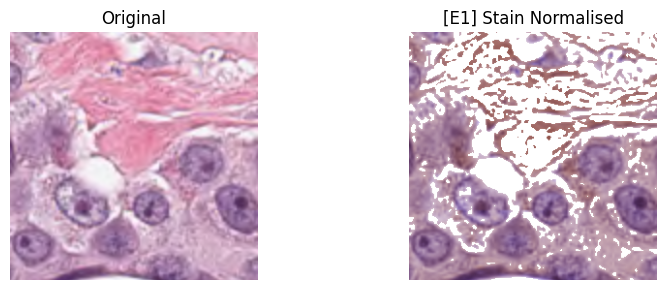

RAM: 1.6/13.6 GB (14%)  |  GPU alloc=0.00GB reserved=0.00GB


In [ ]:
# Fit stain normaliser on one representative image
# RAM tip: we load ONLY this one image, fit, then it's done
normalizer = MacenkoNormalizer()
ref_img    = images[eval_indices[1]].astype(np.uint8)  # copy to RAM
normalizer.fit(ref_img)
del ref_img
free_ram()

# Quick visual check
test_raw  = images[eval_indices[2]].astype(np.uint8)
test_norm = normalizer.transform(test_raw)

fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].imshow(test_raw);  axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(test_norm); axes[1].set_title('[E1] Stain Normalised'); axes[1].axis('off')
plt.tight_layout(); plt.show()

del test_raw, test_norm
free_ram()
print_ram()

## Section 6 — Load SAM ViT-B

In [ ]:
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
print('SAM ViT-B weights downloaded.')

SAM ViT-B weights downloaded.


In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

# ── RAM tip: load model once, keep on GPU ─────────────────────
# Never move it back to CPU — that doubles peak RAM usage
sam = sam_model_registry['vit_b'](checkpoint='sam_vit_b_01ec64.pth')
sam.to(device)
sam.eval()   # eval mode disables dropout and batch-norm updates

predictor = SamPredictor(sam)

free_ram()
print('SAM ViT-B loaded.')
print_ram()

Device: cuda
SAM ViT-B loaded.
RAM: 2.5/13.6 GB (21%)  |  GPU alloc=0.37GB reserved=0.42GB


## Section 7 — AMG Configurations

In [ ]:
# ════════════════════════════════════════════════════════════
# RAM TIP: Only ONE mask_generator object at a time.
# We use strict by default and switch per-image as needed.
# ════════════════════════════════════════════════════════════

# ── ORIGINAL AMG (kept for baseline, run separately) ─────────
mask_generator_original = SamAutomaticMaskGenerator(
    sam,
    points_per_side        = 32,
    pred_iou_thresh        = 0.70,
    stability_score_thresh = 0.80,
    min_mask_region_area   = 30,
)

# ── STRICT AMG — default (good precision, dense images) ──────
mask_generator_strict = SamAutomaticMaskGenerator(
    sam,
    points_per_side        = 16,   # fewer points → fewer masks
    pred_iou_thresh        = 0.86, # high confidence only
    stability_score_thresh = 0.90,
    min_mask_region_area   = 150,  # no tiny artifacts
    box_nms_thresh         = 0.5,
    crop_n_layers          = 0,    # no cropping → faster + less RAM
)

# ── PERMISSIVE AMG — fallback (sparse/lightly-stained images) ─
mask_generator_permissive = SamAutomaticMaskGenerator(
    sam,
    points_per_side        = 24,
    pred_iou_thresh        = 0.78,
    stability_score_thresh = 0.85,
    min_mask_region_area   = 80,
    box_nms_thresh         = 0.6,
    crop_n_layers          = 0,
)

# Instantiate balanced filter
morph_filter = BalancedMorphologyFilter(
    area_min=60, area_max=3500,
    solidity_min=0.50, eccentricity_max=0.95,
    extent_min=0.28, intensity_margin=0.35,
    min_keep=3, fallback_k=8
)

print('AMG configurations and filter ready.')
print_ram()

AMG configurations and filter ready.
RAM: 2.5/13.6 GB (21%)  |  GPU alloc=0.37GB reserved=0.42GB


## Section 8 — Quick Single-Image Demo

Original AMG : 225 masks
Strict AMG   : 66 masks
After NMS    : 50 masks
After filter : 16 masks


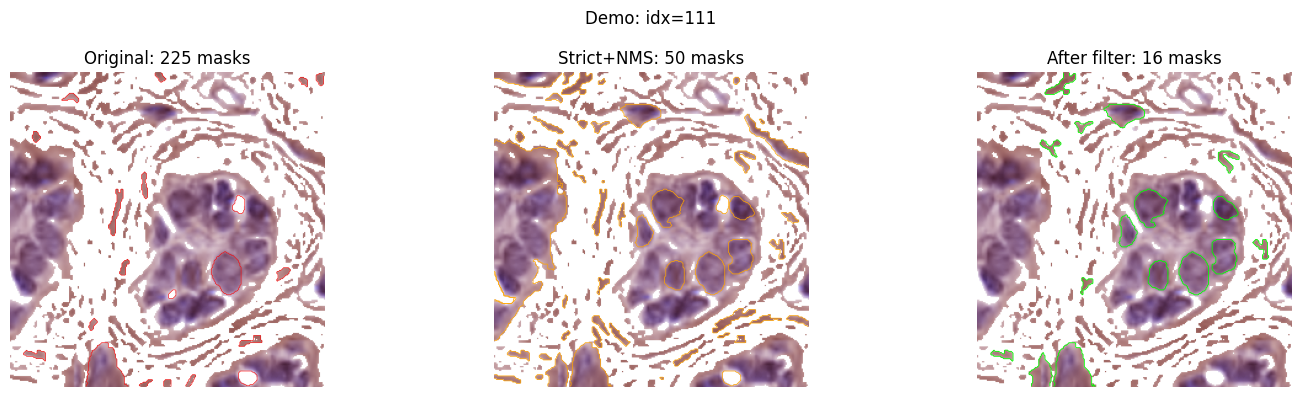

RAM: 2.8/13.6 GB (23%)  |  GPU alloc=0.38GB reserved=0.42GB


In [ ]:
# Demo on first valid image — shows before/after
# RAM tip: use 256x256 for demo (original size) to save GPU RAM
demo_idx = eval_indices[0]
img_demo = normalizer.transform(images[demo_idx].astype(np.uint8))
# No resize — keep at 256x256
gray_demo = cv2.cvtColor(img_demo, cv2.COLOR_RGB2GRAY)

with torch.no_grad():
    masks_orig_demo = mask_generator_original.generate(img_demo)
    masks_str_demo  = mask_generator_strict.generate(img_demo)

nms_demo = mask_nms(masks_str_demo, iou_threshold=0.3, max_masks=50)
acc_demo, _ = morph_filter.filter_masks(nms_demo, gray_demo)

print(f'Original AMG : {len(masks_orig_demo)} masks')
print(f'Strict AMG   : {len(masks_str_demo)} masks')
print(f'After NMS    : {len(nms_demo)} masks')
print(f'After filter : {len(acc_demo)} masks')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(img_demo)
for m in masks_orig_demo[:20]:
    axes[0].contour(m['segmentation'], colors='red', linewidths=0.4)
axes[0].set_title(f'Original: {len(masks_orig_demo)} masks'); axes[0].axis('off')

axes[1].imshow(img_demo)
for m in nms_demo:
    axes[1].contour(m['segmentation'], colors='orange', linewidths=0.5)
axes[1].set_title(f'Strict+NMS: {len(nms_demo)} masks'); axes[1].axis('off')

axes[2].imshow(img_demo)
for m in acc_demo:
    axes[2].contour(m['segmentation'], colors='lime', linewidths=0.6)
axes[2].set_title(f'After filter: {len(acc_demo)} masks'); axes[2].axis('off')

plt.suptitle(f'Demo: idx={demo_idx}')
plt.tight_layout(); plt.show()

# Free demo data
del masks_orig_demo, masks_str_demo, nms_demo, acc_demo
del img_demo, gray_demo
free_ram()
print_ram()

## Section 9 — Main Pipeline: 20 Images (RAM-Safe Loop)

In [ ]:
# ════════════════════════════════════════════════════════════
# RAM-SAFE MAIN LOOP
# Key principle: EVERY large variable is deleted at end of
# each iteration. Only tiny metric dicts (floats) are kept.
#
# Memory budget per iteration:
#   image_i      : 256x256x3 uint8   = 0.2 MB
#   SAM masks    : ~30 x 256x256     = 2 MB peak (freed after NMS)
#   combined_mask: 256x256 float32   = 0.3 MB
#   instance_mask: 256x256 int32     = 0.3 MB
#   gt_instances : ~20 x 256x256     = 1.3 MB (freed after eval)
#   pred_instances: ~10 x 256x256    = 0.7 MB (freed after eval)
# Total peak per image: ~5 MB — negligible
# ════════════════════════════════════════════════════════════

amg_metrics      = []   # list of small dicts — no mask arrays stored
zero_det_count   = 0

for loop_i, img_idx in enumerate(eval_indices):
    print(f'\n[{loop_i+1}/{N_EVAL}] idx={img_idx}', end='  ')

    # ── Load single image from disk (mmap) ───────────────────
    image_i   = normalizer.transform(images[img_idx].astype(np.uint8))
    # Keep at NATIVE 256x256 — saves 4x GPU memory vs 512x512
    gray_i    = cv2.cvtColor(image_i, cv2.COLOR_RGB2GRAY)

    # Load GT mask for this image only
    gt_raw    = masks[img_idx].astype(np.float32)  # 256x256x5
    gt_bin_i  = (gt_raw.sum(axis=-1) > 0).astype(np.uint8)
    gt_insts_i = extract_gt_instances(gt_raw)
    del gt_raw   # free immediately after extracting instances

    # ── Dual-threshold AMG ───────────────────────────────────
    with torch.no_grad():
        raw_strict = mask_generator_strict.generate(image_i)

    nms_strict  = mask_nms(raw_strict, iou_threshold=0.3, max_masks=50)
    del raw_strict   # free raw masks immediately
    acc_i, _    = morph_filter.filter_masks(nms_strict, gray_i)
    del nms_strict

    amg_mode = 'strict'
    if len(acc_i) < 5:
        # Fallback to permissive AMG
        with torch.no_grad():
            raw_perm = mask_generator_permissive.generate(image_i)
        nms_perm  = mask_nms(raw_perm, iou_threshold=0.4, max_masks=50)
        del raw_perm
        acc_perm, _ = morph_filter.filter_masks(nms_perm, gray_i)
        del nms_perm
        if len(acc_perm) > len(acc_i):
            acc_i    = acc_perm
            amg_mode = 'permissive'
        else:
            del acc_perm

    free_ram()   # clear CUDA cache after SAM inference

    # ── Build combined binary mask ────────────────────────────
    combined_i = np.zeros(image_i.shape[:2], dtype=np.float32)
    for m in acc_i:
        combined_i[m['segmentation']] = 1.0
    del acc_i   # free mask list

    # ── Watershed ────────────────────────────────────────────
    inst_i     = balanced_watershed(combined_i, min_area=60)
    pred_bin_i = (inst_i > 0).astype(np.uint8)
    del combined_i

    pred_insts_i = extract_pred_instances(inst_i)
    del inst_i

    if len(pred_insts_i) == 0:
        zero_det_count += 1

    # ── Evaluate — store only small floats ───────────────────
    m = full_eval(pred_insts_i, gt_insts_i, pred_bin_i, gt_bin_i)
    amg_metrics.append(m)

    print(f'mode={amg_mode} GT={len(gt_insts_i)} '
          f'Pred={len(pred_insts_i)} '
          f'MSA={m["MSA"]:.4f} '
          f'Prec={m["Precision@0.5"]:.3f} '
          f'Rec={m["Recall@0.5"]:.3f}')

    # ── FREE EVERYTHING from this iteration ──────────────────
    del image_i, gray_i, gt_bin_i
    del gt_insts_i, pred_insts_i, pred_bin_i
    free_ram()

print(f'\n===== AMG RESULTS ({N_EVAL} images) =====')
print(f'Zero-detection: {zero_det_count}/{N_EVAL}')
for key in ['MSA','Precision@0.5','Recall@0.5','F1@0.5','Pixel_Dice']:
    v = [m[key] for m in amg_metrics]
    print(f'  {key:<18s}: {np.mean(v):.4f} ± {np.std(v):.4f}')
print_ram()


[1/20] idx=111  mode=strict GT=34 Pred=28 MSA=0.0971 Prec=0.321 Rec=0.265

[2/20] idx=2425      [Fallback] top-2 masks used.
mode=permissive GT=69 Pred=48 MSA=0.1887 Prec=0.646 Rec=0.449

[3/20] idx=705  mode=strict GT=16 Pred=27 MSA=0.1602 Prec=0.296 Rec=0.500

[4/20] idx=56  mode=strict GT=16 Pred=25 MSA=0.0518 Prec=0.240 Rec=0.375

[5/20] idx=902      [Fallback] top-1 masks used.
    [Fallback] top-1 masks used.
mode=strict GT=47 Pred=1 MSA=0.0106 Prec=1.000 Rec=0.021

[6/20] idx=2534      [Fallback] top-1 masks used.
    [Fallback] top-1 masks used.
mode=strict GT=26 Pred=1 MSA=0.0231 Prec=1.000 Rec=0.038

[7/20] idx=2563  mode=strict GT=14 Pred=14 MSA=0.1877 Prec=0.429 Rec=0.429

[8/20] idx=2339  mode=strict GT=38 Pred=34 MSA=0.1285 Prec=0.412 Rec=0.368

[9/20] idx=1330  mode=strict GT=21 Pred=25 MSA=0.1392 Prec=0.360 Rec=0.429

[10/20] idx=2358  mode=strict GT=17 Pred=12 MSA=0.0631 Prec=0.250 Rec=0.176

[11/20] idx=746  mode=strict GT=12 Pred=16 MSA=0.3557 Prec=0.625 Rec=0.833



## Section 10 — UICE Loop (RAM-Safe)

In [ ]:
# ════════════════════════════════════════════════════════════
# UICE LOOP — RAM-safe
# Only set_image() once per image (expensive encoder pass).
# Each nucleus prediction frees its tensors immediately.
# ════════════════════════════════════════════════════════════

uice_msa_scores  = []
uice_iter_counts = []

for loop_i, img_idx in enumerate(eval_indices):
    print(f'[{loop_i+1}/{N_EVAL}] idx={img_idx}', end='  ')

    image_i   = normalizer.transform(images[img_idx].astype(np.uint8))
    gt_raw    = masks[img_idx].astype(np.float32)
    gt_insts_i = extract_gt_instances(gt_raw)
    del gt_raw

    # Encode image ONCE — expensive GPU op, store in predictor
    image_rgb = cv2.cvtColor(image_i.astype(np.uint8), cv2.COLOR_BGR2RGB)
    with torch.no_grad():
        predictor.set_image(image_rgb)
    del image_rgb
    free_ram()

    pred_insts = []
    img_iters  = []

    for gt_inst in gt_insts_i:
        y, x = np.where(gt_inst)
        if len(x) == 0: continue

        initial_pt = (int(x.mean()), int(y.mean()))
        box        = get_bbox(gt_inst, padding=3)

        try:
            with torch.no_grad():
                pred_mask, n_iters = uice_refine(
                    predictor,
                    initial_point     = initial_pt,
                    bbox              = box,
                    n_iterations      = 6,
                    top_k             = 2,
                    entropy_threshold = 0.08,
                    min_improvement   = 0.005
                )
            pred_insts.append(pred_mask.astype(np.uint8))
            img_iters.append(n_iters)
            del pred_mask
        except Exception:
            # Fallback: simple point prompt
            try:
                with torch.no_grad():
                    mp, sc, _ = predictor.predict(
                        point_coords=np.array([[initial_pt[0], initial_pt[1]]]),
                        point_labels=np.array([1]),
                        multimask_output=True
                    )
                pred_insts.append(mp[np.argmax(sc)].astype(np.uint8))
                img_iters.append(1)
                del mp, sc
            except Exception:
                pass

    msa = compute_msa(pred_insts, gt_insts_i) if pred_insts else 0.0
    uice_msa_scores.append(msa)
    avg_it = np.mean(img_iters) if img_iters else 0
    uice_iter_counts.extend(img_iters)

    print(f'GT={len(gt_insts_i)} Pred={len(pred_insts)} '
          f'MSA={msa:.4f} AvgIter={avg_it:.1f}')

    del image_i, gt_insts_i, pred_insts, img_iters
    free_ram()

print(f'\nAverage MSA (UICE): {np.mean(uice_msa_scores):.4f}')
print(f'Avg iterations    : {np.mean(uice_iter_counts):.2f} of 6')
print_ram()

[1/20] idx=111  GT=34 Pred=34 MSA=0.1434 AvgIter=5.4
[2/20] idx=2425  GT=69 Pred=69 MSA=0.2925 AvgIter=5.2
[3/20] idx=705  GT=16 Pred=16 MSA=0.4009 AvgIter=4.9
[4/20] idx=56  GT=16 Pred=16 MSA=0.1630 AvgIter=5.1
[5/20] idx=902  GT=47 Pred=47 MSA=0.3630 AvgIter=4.9
[6/20] idx=2534  GT=26 Pred=26 MSA=0.1747 AvgIter=5.7
[7/20] idx=2563  GT=14 Pred=14 MSA=0.2471 AvgIter=4.6
[8/20] idx=2339  GT=38 Pred=38 MSA=0.3886 AvgIter=5.4
[9/20] idx=1330  GT=21 Pred=21 MSA=0.1672 AvgIter=5.2
[10/20] idx=2358  GT=17 Pred=17 MSA=0.2023 AvgIter=5.7
[11/20] idx=746  GT=12 Pred=12 MSA=0.5711 AvgIter=5.7
[12/20] idx=536  GT=22 Pred=22 MSA=0.3283 AvgIter=5.4
[13/20] idx=532  GT=30 Pred=30 MSA=0.2792 AvgIter=5.3
[14/20] idx=1394  GT=16 Pred=16 MSA=0.4872 AvgIter=5.0
[15/20] idx=425  GT=22 Pred=22 MSA=0.4060 AvgIter=5.0
[16/20] idx=2504  GT=41 Pred=41 MSA=0.3669 AvgIter=5.0
[17/20] idx=688  GT=36 Pred=36 MSA=0.2116 AvgIter=4.7
[18/20] idx=1365  GT=18 Pred=18 MSA=0.1738 AvgIter=5.1
[19/20] idx=1565  GT=15 Pred=

## Section 11 — BBox Prompted SAM (Oracle)

In [ ]:
bbox_msa_scores = []

for loop_i, img_idx in enumerate(eval_indices):
    print(f'[{loop_i+1}/{N_EVAL}] idx={img_idx}', end='  ')

    image_i    = normalizer.transform(images[img_idx].astype(np.uint8))
    gt_raw     = masks[img_idx].astype(np.float32)
    gt_insts_i = extract_gt_instances(gt_raw)
    del gt_raw

    image_rgb = cv2.cvtColor(image_i.astype(np.uint8), cv2.COLOR_BGR2RGB)
    with torch.no_grad():
        predictor.set_image(image_rgb)
    del image_rgb

    pred_insts = []
    for gt_inst in gt_insts_i:
        box = get_bbox(gt_inst, padding=3)
        if box is None: continue
        try:
            with torch.no_grad():
                mp, sc, _ = predictor.predict(box=box, multimask_output=True)
            pred_insts.append(mp[np.argmax(sc)].astype(np.uint8))
            del mp, sc
        except Exception:
            pass

    msa = compute_msa(pred_insts, gt_insts_i) if pred_insts else 0.0
    bbox_msa_scores.append(msa)
    print(f'GT={len(gt_insts_i)} Pred={len(pred_insts)} MSA={msa:.4f}')

    del image_i, gt_insts_i, pred_insts
    free_ram()

print(f'\nAverage MSA (BBox oracle): {np.mean(bbox_msa_scores):.4f}')
print_ram()

[1/20] idx=111  GT=34 Pred=34 MSA=0.3376
[2/20] idx=2425  GT=69 Pred=69 MSA=0.4769
[3/20] idx=705  GT=16 Pred=16 MSA=0.5671
[4/20] idx=56  GT=16 Pred=16 MSA=0.2475
[5/20] idx=902  GT=47 Pred=47 MSA=0.5281
[6/20] idx=2534  GT=26 Pred=26 MSA=0.3890
[7/20] idx=2563  GT=14 Pred=14 MSA=0.4700
[8/20] idx=2339  GT=38 Pred=38 MSA=0.5191
[9/20] idx=1330  GT=21 Pred=21 MSA=0.4615
[10/20] idx=2358  GT=17 Pred=17 MSA=0.4786
[11/20] idx=746  GT=12 Pred=12 MSA=0.5421
[12/20] idx=536  GT=22 Pred=22 MSA=0.5768
[13/20] idx=532  GT=30 Pred=30 MSA=0.5038
[14/20] idx=1394  GT=16 Pred=16 MSA=0.6397
[15/20] idx=425  GT=22 Pred=22 MSA=0.6333
[16/20] idx=2504  GT=41 Pred=41 MSA=0.4716
[17/20] idx=688  GT=36 Pred=36 MSA=0.3453
[18/20] idx=1365  GT=18 Pred=18 MSA=0.3629
[19/20] idx=1565  GT=15 Pred=15 MSA=0.2542
[20/20] idx=2214  GT=15 Pred=15 MSA=0.4300

Average MSA (BBox oracle): 0.4618
RAM: 3.0/13.6 GB (25%)  |  GPU alloc=0.39GB reserved=0.44GB


## Section 12 — GT-Guided Iterative SAM (Original, Reference)

In [ ]:
iter_msa_scores = []

for loop_i, img_idx in enumerate(eval_indices):
    print(f'[{loop_i+1}/{N_EVAL}] idx={img_idx}', end='  ')

    image_i    = normalizer.transform(images[img_idx].astype(np.uint8))
    gt_raw     = masks[img_idx].astype(np.float32)
    gt_insts_i = extract_gt_instances(gt_raw)
    del gt_raw

    image_rgb = cv2.cvtColor(image_i.astype(np.uint8), cv2.COLOR_BGR2RGB)
    with torch.no_grad():
        predictor.set_image(image_rgb)
    del image_rgb

    pred_insts = []
    for gt_inst in gt_insts_i:
        y, x = np.where(gt_inst)
        if len(x) == 0: continue
        pts  = [[float(x.mean()), float(y.mean())]]
        lbls = [1]
        pm   = None
        for _ in range(6):   # reduced from 8 to 6 for speed
            try:
                with torch.no_grad():
                    mp, sc, _ = predictor.predict(
                        point_coords=np.array(pts),
                        point_labels=np.array(lbls),
                        multimask_output=True
                    )
                pm = mp[np.argmax(sc)]
                fn = np.logical_and(gt_inst==1, pm==0)
                fp = np.logical_and(gt_inst==0, pm==1)
                del mp, sc
                if fn.sum() > 0:
                    yf, xf = np.where(fn)
                    pts.append([float(xf.mean()), float(yf.mean())])
                    lbls.append(1)
                elif fp.sum() > 0:
                    yf, xf = np.where(fp)
                    pts.append([float(xf.mean()), float(yf.mean())])
                    lbls.append(0)
                else:
                    break
                del fn, fp
            except Exception:
                break
        if pm is not None:
            pred_insts.append(pm.astype(np.uint8))
            del pm

    msa = compute_msa(pred_insts, gt_insts_i) if pred_insts else 0.0
    iter_msa_scores.append(msa)
    print(f'GT={len(gt_insts_i)} Pred={len(pred_insts)} MSA={msa:.4f}')

    del image_i, gt_insts_i, pred_insts
    free_ram()

print(f'\nAverage MSA (GT-guided iterative): {np.mean(iter_msa_scores):.4f}')
print_ram()

[1/20] idx=111  GT=34 Pred=34 MSA=0.1658
[2/20] idx=2425  GT=69 Pred=69 MSA=0.3199
[3/20] idx=705  GT=16 Pred=16 MSA=0.5128
[4/20] idx=56  GT=16 Pred=16 MSA=0.1385
[5/20] idx=902  GT=47 Pred=47 MSA=0.4099
[6/20] idx=2534  GT=26 Pred=26 MSA=0.2311
[7/20] idx=2563  GT=14 Pred=14 MSA=0.3470
[8/20] idx=2339  GT=38 Pred=38 MSA=0.4363
[9/20] idx=1330  GT=21 Pred=21 MSA=0.2444
[10/20] idx=2358  GT=17 Pred=17 MSA=0.1982
[11/20] idx=746  GT=12 Pred=12 MSA=0.5957
[12/20] idx=536  GT=22 Pred=22 MSA=0.4138
[13/20] idx=532  GT=30 Pred=30 MSA=0.4040
[14/20] idx=1394  GT=16 Pred=16 MSA=0.4095
[15/20] idx=425  GT=22 Pred=22 MSA=0.5196
[16/20] idx=2504  GT=41 Pred=41 MSA=0.4414
[17/20] idx=688  GT=36 Pred=36 MSA=0.1877
[18/20] idx=1365  GT=18 Pred=18 MSA=0.0972
[19/20] idx=1565  GT=15 Pred=15 MSA=0.1158
[20/20] idx=2214  GT=15 Pred=15 MSA=0.2282

Average MSA (GT-guided iterative): 0.3208
RAM: 3.0/13.6 GB (25%)  |  GPU alloc=0.39GB reserved=0.44GB


## Section 13 — Results, Plots and Summary

In [ ]:
# ── Per-image metrics table ───────────────────────────────────
print('Per-image metrics — v4 Balanced AMG (20 images)')
print(f'{"#":>3}{"Idx":>5}{"MSA":>8}{"Dice":>8}'
      f'{"Prec@.5":>9}{"Rec@.5":>8}{"F1@.5":>8}'
      f'{"NPred":>7}{"NGT":>6}')
print('-' * 66)
for i, (idx, m) in enumerate(zip(eval_indices, amg_metrics)):
    flag = ' ← 0!' if m['N_pred'] == 0 else ''
    print(f'{i+1:>3}{idx:>5}'
          f'{m["MSA"]:>8.4f}'
          f'{m["Pixel_Dice"]:>8.4f}'
          f'{m["Precision@0.5"]:>9.4f}'
          f'{m["Recall@0.5"]:>8.4f}'
          f'{m["F1@0.5"]:>8.4f}'
          f'{m["N_pred"]:>7}'
          f'{m["N_gt"]:>6}{flag}')

print('-' * 66)
means = {k: np.mean([m[k] for m in amg_metrics])
         for k in ['MSA','Pixel_Dice','Precision@0.5','Recall@0.5','F1@0.5']}
print(f'{"Mean":>8}'
      f'{means["MSA"]:>8.4f}'
      f'{means["Pixel_Dice"]:>8.4f}'
      f'{means["Precision@0.5"]:>9.4f}'
      f'{means["Recall@0.5"]:>8.4f}'
      f'{means["F1@0.5"]:>8.4f}')
print(f'\nZero-detection images: {zero_det_count}/{N_EVAL}')

Per-image metrics — v4 Balanced AMG (20 images)
  #  Idx     MSA    Dice  Prec@.5  Rec@.5   F1@.5  NPred   NGT
------------------------------------------------------------------
  1  111  0.0971  0.1384   0.3214  0.2647  0.2903     28    34
  2 2425  0.1887  0.1977   0.6458  0.4493  0.5299     48    69
  3  705  0.1602  0.3041   0.2963  0.5000  0.3721     27    16
  4   56  0.0518  0.2275   0.2400  0.3750  0.2927     25    16
  5  902  0.0106  1.0000   1.0000  0.0213  0.0417      1    47
  6 2534  0.0231  1.0000   1.0000  0.0385  0.0741      1    26
  7 2563  0.1877  0.0921   0.4286  0.4286  0.4286     14    14
  8 2339  0.1285  0.2273   0.4118  0.3684  0.3889     34    38
  9 1330  0.1392  0.1628   0.3600  0.4286  0.3913     25    21
 10 2358  0.0631  0.1079   0.2500  0.1765  0.2069     12    17
 11  746  0.3557  0.1088   0.6250  0.8333  0.7143     16    12
 12  536  0.1525  0.1978   0.3750  0.4091  0.3913     24    22
 13  532  0.1369  0.3388   0.3125  0.5000  0.3846     48    30
 14

In [ ]:
# ── Final comparison ──────────────────────────────────────────
avg_amg  = np.mean([m['MSA'] for m in amg_metrics])
avg_uice = np.mean(uice_msa_scores)
avg_bbox = np.mean(bbox_msa_scores)
avg_iter = np.mean(iter_msa_scores)

# v3 reference values from screenshots
v3_refs = {'AMG': 0.059, 'UICE': 0.143, 'BBox': 0.447, 'Iter': 0.215}

print('=' * 65)
print('FINAL RESULTS — ALL METHODS (20 images, seed=42)')
print('=' * 65)
for name, val, v3 in [
    ('v4 AMG [automatic]',    avg_amg,  v3_refs['AMG']),
    ('BBox [oracle]',         avg_bbox, v3_refs['BBox']),
    ('GT-Iterative [oracle]', avg_iter, v3_refs['Iter']),
    ('UICE v4 [no GT]',       avg_uice, v3_refs['UICE']),
]:
    delta = val - v3
    arrow = '↑' if delta > 0 else '↓'
    bar   = '█' * int(val * 50)
    print(f'  {name:<28s} {val:.4f} '
          f'(v3={v3:.3f} {arrow}{abs(delta):.3f})  {bar}')

print()
v4_prec = np.mean([m['Precision@0.5'] for m in amg_metrics])
v4_rec  = np.mean([m['Recall@0.5']    for m in amg_metrics])
print('── Precision / Recall balance ──')
print(f'  Precision: v3=0.258 → v4={v4_prec:.3f}')
print(f'  Recall   : v3=0.137 → v4={v4_rec:.3f}')
print(f'  Zero-det : v3=~6    → v4={zero_det_count}')
print('=' * 65)

FINAL RESULTS — ALL METHODS (20 images, seed=42)
  v4 AMG [automatic]           0.1470 (v3=0.059 ↑0.088)  ███████
  BBox [oracle]                0.4618 (v3=0.447 ↑0.015)  ███████████████████████
  GT-Iterative [oracle]        0.3208 (v3=0.215 ↑0.106)  ████████████████
  UICE v4 [no GT]              0.2899 (v3=0.143 ↑0.147)  ██████████████

── Precision / Recall balance ──
  Precision: v3=0.258 → v4=0.465
  Recall   : v3=0.137 → v4=0.422
  Zero-det : v3=~6    → v4=0


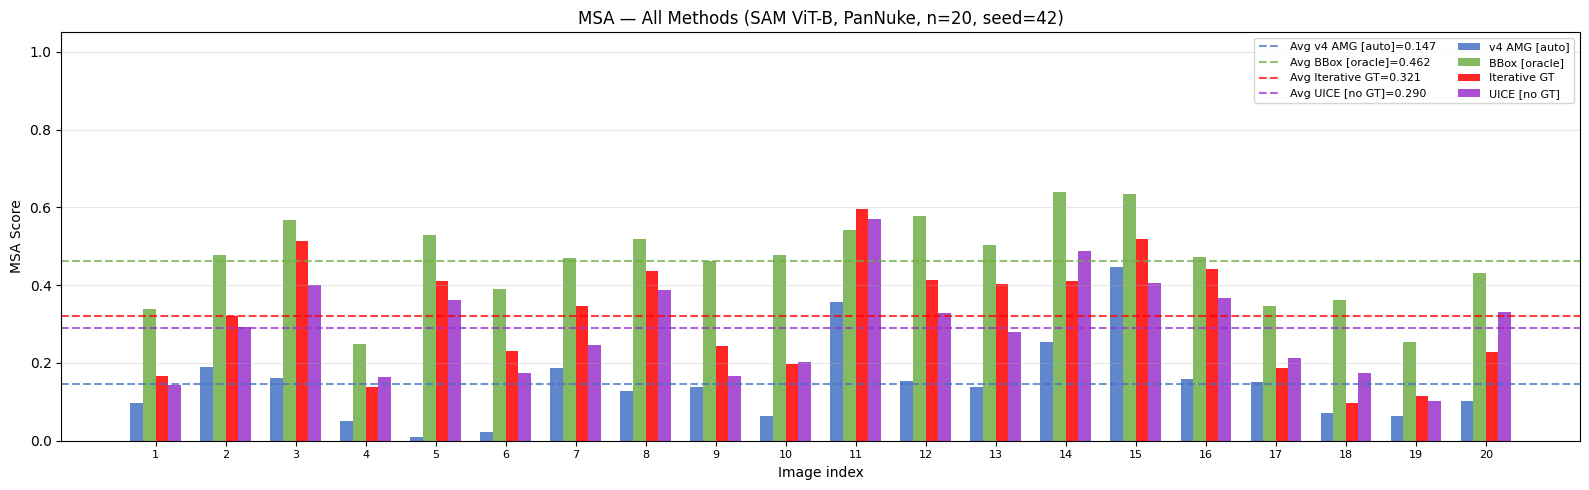

In [ ]:
# ── Plot 1: Per-image MSA all methods ─────────────────────────
n = N_EVAL
x = np.arange(n)
w = 0.18

all_data = [
    ([m['MSA'] for m in amg_metrics], 'v4 AMG [auto]',  '#4472C4'),
    (bbox_msa_scores,                 'BBox [oracle]',  '#70AD47'),
    (iter_msa_scores,                 'Iterative GT',   '#FF0000'),
    (uice_msa_scores,                 'UICE [no GT]',   '#9932CC'),
]

fig, ax = plt.subplots(figsize=(16, 5))
for (data, lbl, color), offset in zip(all_data,
                                       np.array([-1.5,-0.5,0.5,1.5])*w):
    ax.bar(x+offset, data[:n], w, label=lbl, color=color, alpha=0.85)
    avg = np.mean(data)
    ax.axhline(avg, color=color, linestyle='--', linewidth=1.5,
               alpha=0.75, label=f'Avg {lbl}={avg:.3f}')

ax.set_xlabel('Image index')
ax.set_ylabel('MSA Score')
ax.set_title(f'MSA — All Methods (SAM ViT-B, PanNuke, n={n}, seed=42)')
ax.set_xticks(x)
ax.set_xticklabels([str(i+1) for i in range(n)], fontsize=8)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=8, ncol=2, loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

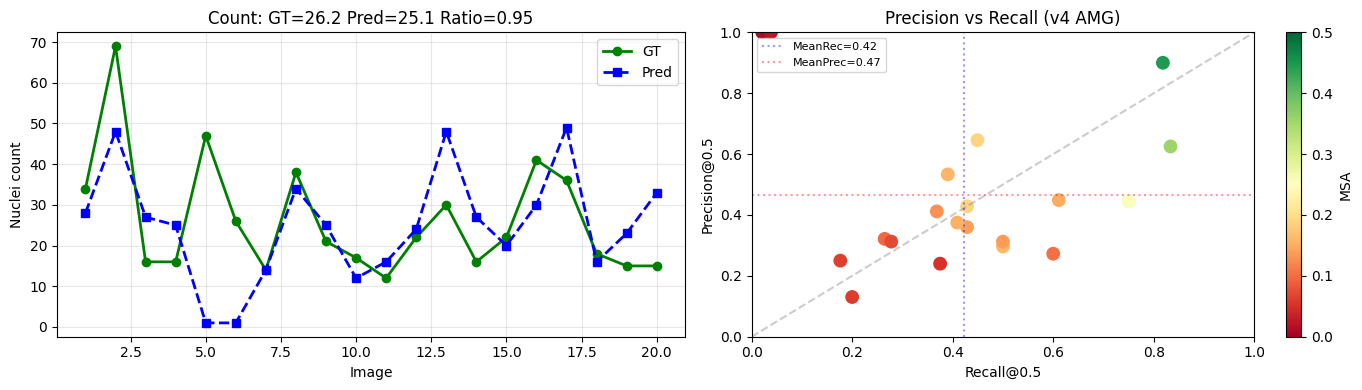

In [ ]:
# ── Plot 2: NPred vs NGT ──────────────────────────────────────
n_pred = [m['N_pred'] for m in amg_metrics]
n_gt   = [m['N_gt']   for m in amg_metrics]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(range(1,n+1), n_gt,   'g-o', label='GT',   lw=2)
axes[0].plot(range(1,n+1), n_pred, 'b--s', label='Pred', lw=2)
axes[0].set_title(f'Count: GT={np.mean(n_gt):.1f} Pred={np.mean(n_pred):.1f} '
                  f'Ratio={np.mean(n_pred)/(np.mean(n_gt)+1e-6):.2f}')
axes[0].set_xlabel('Image'); axes[0].set_ylabel('Nuclei count')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Precision / Recall scatter
prec_v = [m['Precision@0.5'] for m in amg_metrics]
rec_v  = [m['Recall@0.5']    for m in amg_metrics]
sc = axes[1].scatter(rec_v, prec_v,
                     c=[m['MSA'] for m in amg_metrics],
                     cmap='RdYlGn', s=80, vmin=0, vmax=0.5)
plt.colorbar(sc, ax=axes[1], label='MSA')
axes[1].plot([0,1],[0,1],'--',color='gray',alpha=0.4)
axes[1].axvline(np.mean(rec_v),  color='blue', alpha=0.4,
                linestyle=':', label=f'MeanRec={np.mean(rec_v):.2f}')
axes[1].axhline(np.mean(prec_v), color='red',  alpha=0.4,
                linestyle=':', label=f'MeanPrec={np.mean(prec_v):.2f}')
axes[1].set_xlabel('Recall@0.5'); axes[1].set_ylabel('Precision@0.5')
axes[1].set_xlim(0,1); axes[1].set_ylim(0,1)
axes[1].set_title('Precision vs Recall (v4 AMG)')
axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

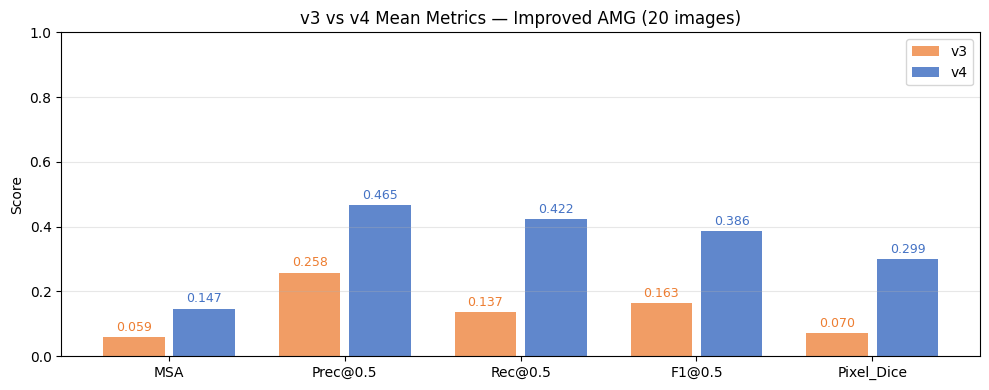

In [ ]:
# ── Plot 3: v3 vs v4 metric comparison ───────────────────────
metric_names = ['MSA', 'Prec@0.5', 'Rec@0.5', 'F1@0.5', 'Pixel_Dice']
v4_vals = [
    np.mean([m['MSA']            for m in amg_metrics]),
    np.mean([m['Precision@0.5']  for m in amg_metrics]),
    np.mean([m['Recall@0.5']     for m in amg_metrics]),
    np.mean([m['F1@0.5']         for m in amg_metrics]),
    np.mean([m['Pixel_Dice']     for m in amg_metrics]),
]
v3_vals = [0.059, 0.258, 0.137, 0.163, 0.070]

bx = np.arange(len(metric_names))
fig, ax = plt.subplots(figsize=(10, 4))
b1 = ax.bar(bx-0.2, v3_vals, 0.35, label='v3', color='#ED7D31', alpha=0.75)
b2 = ax.bar(bx+0.2, v4_vals, 0.35, label='v4', color='#4472C4', alpha=0.85)
ax.set_xticks(bx); ax.set_xticklabels(metric_names)
ax.set_ylim(0, 1); ax.set_ylabel('Score')
ax.set_title('v3 vs v4 Mean Metrics — Improved AMG (20 images)')
ax.legend(); ax.grid(axis='y', alpha=0.3)
for b, v in zip(b2, v4_vals):
    ax.text(b.get_x()+b.get_width()/2, v+0.01, f'{v:.3f}',
            ha='center', va='bottom', fontsize=9, color='#4472C4')
for b, v in zip(b1, v3_vals):
    ax.text(b.get_x()+b.get_width()/2, v+0.01, f'{v:.3f}',
            ha='center', va='bottom', fontsize=9, color='#ED7D31')
plt.tight_layout(); plt.show()

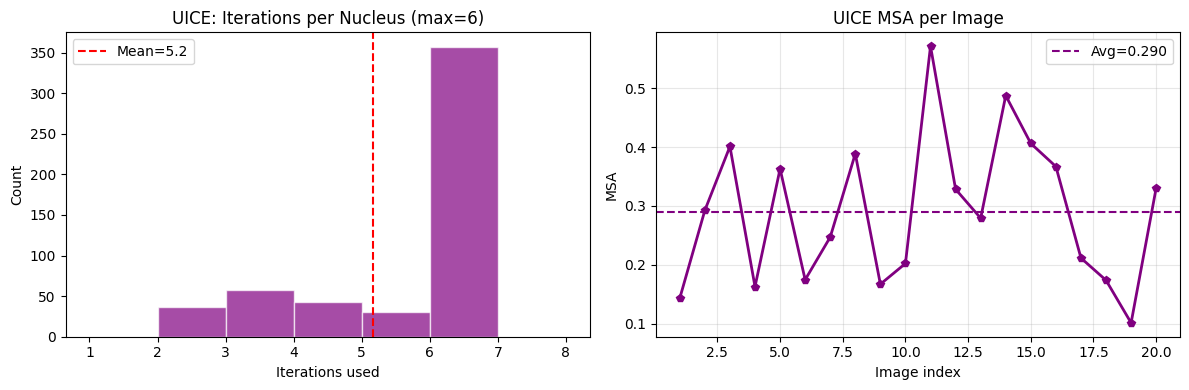

In [ ]:
# ── Plot 4: UICE iterations histogram ────────────────────────
if uice_iter_counts:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(uice_iter_counts, bins=range(1, 9),
                 color='purple', alpha=0.7, edgecolor='white')
    axes[0].axvline(np.mean(uice_iter_counts), color='red',
                    linestyle='--',
                    label=f'Mean={np.mean(uice_iter_counts):.1f}')
    axes[0].set_xlabel('Iterations used')
    axes[0].set_ylabel('Count')
    axes[0].set_title('UICE: Iterations per Nucleus (max=6)')
    axes[0].legend()

    axes[1].plot(range(1,n+1), uice_msa_scores,
                 'p-', color='purple', lw=2, markersize=6)
    axes[1].axhline(np.mean(uice_msa_scores), color='purple',
                    linestyle='--',
                    label=f'Avg={np.mean(uice_msa_scores):.3f}')
    axes[1].set_xlabel('Image index'); axes[1].set_ylabel('MSA')
    axes[1].set_title('UICE MSA per Image')
    axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

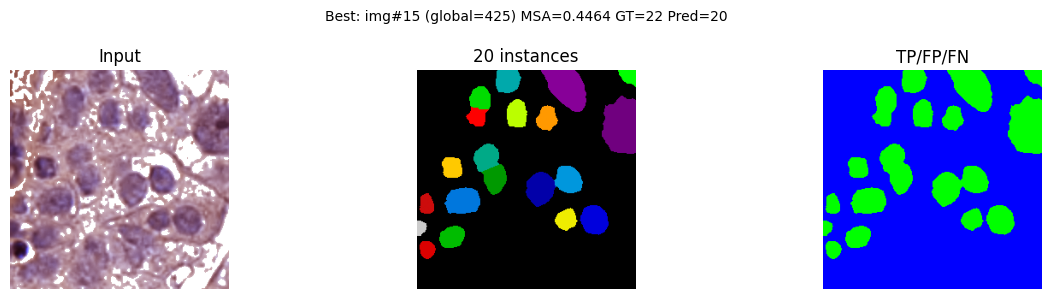

    [Fallback] top-1 masks used.
    [Fallback] top-1 masks used.


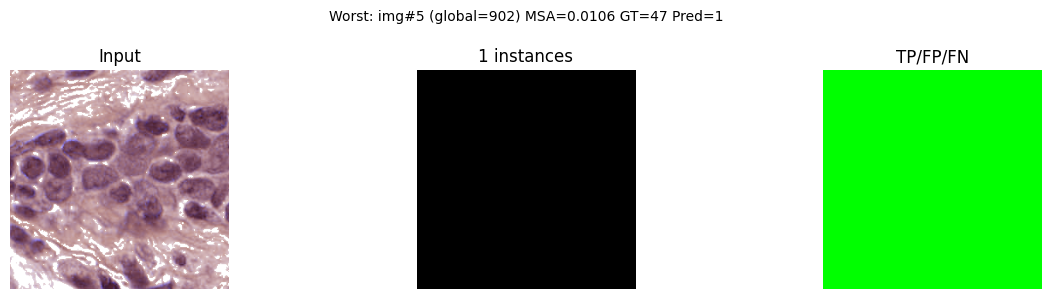

In [ ]:
# ── Qualitative: best and worst images ───────────────────────
msa_list  = [m['MSA'] for m in amg_metrics]
best_idx  = int(np.argmax(msa_list))
worst_idx = int(np.argmin(msa_list))

for title, local_idx in [('Best', best_idx), ('Worst', worst_idx)]:
    img_glob = eval_indices[local_idx]
    img_q    = normalizer.transform(images[img_glob].astype(np.uint8))
    gray_q   = cv2.cvtColor(img_q.astype(np.uint8), cv2.COLOR_RGB2GRAY)
    gt_raw_q = masks[img_glob].astype(np.float32)
    gt_bin_q = (gt_raw_q.sum(axis=-1) > 0).astype(np.uint8)
    del gt_raw_q

    with torch.no_grad():
        raw_q = mask_generator_strict.generate(img_q)
    nms_q  = mask_nms(raw_q, iou_threshold=0.3, max_masks=50)
    del raw_q
    acc_q, _ = morph_filter.filter_masks(nms_q, gray_q)
    del nms_q

    if len(acc_q) < 3:
        with torch.no_grad():
            raw_p = mask_generator_permissive.generate(img_q)
        nms_p  = mask_nms(raw_p, iou_threshold=0.4, max_masks=50)
        del raw_p
        acc_p, _ = morph_filter.filter_masks(nms_p, gray_q)
        del nms_p
        if len(acc_p) > len(acc_q):
            acc_q = acc_p

    comb_q = np.zeros(img_q.shape[:2], dtype=np.float32)
    for m in acc_q:
        comb_q[m['segmentation']] = 1.0
    del acc_q

    inst_q   = balanced_watershed(comb_q, min_area=60)
    pred_q   = (inst_q > 0).astype(np.uint8)
    del comb_q

    vis = np.zeros((*gt_bin_q.shape, 3), dtype=np.float32)
    vis[np.logical_and(gt_bin_q==1, pred_q==1)] = [0, 1, 0]
    vis[np.logical_and(gt_bin_q==0, pred_q==1)] = [1, 0, 0]
    vis[np.logical_and(gt_bin_q==1, pred_q==0)] = [0, 0, 1]

    fig, axes = plt.subplots(1, 3, figsize=(13, 3))
    axes[0].imshow(img_q);         axes[0].set_title('Input');        axes[0].axis('off')
    axes[1].imshow(inst_q, cmap='nipy_spectral')
    axes[1].set_title(f'{inst_q.max()} instances'); axes[1].axis('off')
    axes[2].imshow(vis);           axes[2].set_title('TP/FP/FN');     axes[2].axis('off')
    plt.suptitle(
        f'{title}: img#{local_idx+1} (global={img_glob}) '
        f'MSA={msa_list[local_idx]:.4f} '
        f'GT={amg_metrics[local_idx]["N_gt"]} '
        f'Pred={amg_metrics[local_idx]["N_pred"]}',
        fontsize=10
    )
    plt.tight_layout(); plt.show()

    del img_q, gray_q, gt_bin_q, inst_q, pred_q, vis
    free_ram()

In [ ]:
# ── Final summary ─────────────────────────────────────────────
print('\n' + '='*65)
print('COMPLETE SUMMARY — RAM-OPTIMIZED v4 PIPELINE')
print('='*65)
print(f'Dataset : PanNuke Fold 1, {N_EVAL} images (seed=42, >=5 nuclei)')
print(f'Model   : SAM ViT-B pretrained (no fine-tuning)')
print(f'Device  : {device}')
print()
print('── v4 AMG (automatic) ──')
for k in ['MSA','Precision@0.5','Recall@0.5','F1@0.5','Pixel_Dice']:
    v = [m[k] for m in amg_metrics]
    print(f'  {k:<18s}: {np.mean(v):.4f} ± {np.std(v):.4f}')
print(f'  {"Zero-detection":<18s}: {zero_det_count}/{N_EVAL}')
print()
print('── Prompt-based ──')
print(f'  BBox oracle          : {np.mean(bbox_msa_scores):.4f}')
print(f'  GT-Iterative oracle  : {np.mean(iter_msa_scores):.4f}')
print(f'  UICE (no GT)         : {np.mean(uice_msa_scores):.4f}')
print()
print('── RAM usage at end ──')
print_ram()
print('='*65)


COMPLETE SUMMARY — RAM-OPTIMIZED v4 PIPELINE
Dataset : PanNuke Fold 1, 20 images (seed=42, >=5 nuclei)
Model   : SAM ViT-B pretrained (no fine-tuning)
Device  : cuda

── v4 AMG (automatic) ──
  MSA               : 0.1470 ± 0.1040
  Precision@0.5     : 0.4654 ± 0.2439
  Recall@0.5        : 0.4220 ± 0.2217
  F1@0.5            : 0.3859 ± 0.1911
  Pixel_Dice        : 0.2991 ± 0.2507
  Zero-detection    : 0/20

── Prompt-based ──
  BBox oracle          : 0.4618
  GT-Iterative oracle  : 0.3208
  UICE (no GT)         : 0.2899

── RAM usage at end ──
RAM: 3.0/13.6 GB (25%)  |  GPU alloc=0.39GB reserved=0.44GB
